In [1]:
from sklearn.svm import SVC, SVR, NuSVR, NuSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import gc

import xgboost as xgb

import statsmodels as sm
import tqdm
from sklearn.metrics import roc_auc_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import catboost as cb
from collections import defaultdict

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)

In [2]:
#Load Data

In [3]:
# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv("MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv("WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv("WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv("WNCAATourneySeeds.csv")

In [4]:
M_regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14


In [5]:
# join men's and women's data into one file
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [6]:
season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[(regular_results["Season"] >= season) & (regular_results["Season"] <= 2025)]
tourney_results = tourney_results.loc[(tourney_results["Season"] >= season) & (tourney_results["Season"] <= 2025)]
seeds = seeds.loc[(seeds["Season"] >= season) & (seeds["Season"] <= 2025)]

#### Home/Away

In [7]:
#Define Home/Away, try other possibilities
wloc = {'H':1, 'A':-1, 'N': np.nan} #{'H':1, 'A':0, 'N': 0}  # {'H':1, 'A':-1, 'N': 0} #np.nan} #-1}
#wloc = {'H':1, 'A':-1, 'N': 0} #{'H':1, 'A':0, 'N': 0}  # {'H':1, 'A':-1, 'N': 0} #np.nan} #-1}
regular_results['WHome'] = regular_results['WLoc'].map(lambda x: wloc[x])
regular_results['WHome'].value_counts()

WHome
 1.0    114977
-1.0     66045
Name: count, dtype: int64

In [8]:
tourney_results['WHome'] = tourney_results['WLoc'].map(lambda x: wloc[x])
tourney_results['WHome'].value_counts()

WHome
 1.0    322
-1.0     57
Name: count, dtype: int64

In [9]:
#Prepare Dataset

In [10]:
# # double the dataset with swapped team positions in box scores
# def prepare_data(df):
#     df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT","WHome",
#             "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
#             "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

#     # adjustment factor for overtimes, as more stats are accumulated during overtimes
#     adjot = (40 + 5 * df["NumOT"]) / 40
#     adjcols = ["LScore", "WScore", 
#                "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
#                "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
#     for col in adjcols:
#         df[col] = df[col] / adjot    
    
#     dfswap = df.copy()
#     df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
#     dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
#     output = pd.concat([df, dfswap]).reset_index(drop=True)
#     output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
#     output["win"] = (output["PointDiff"] > 0) * 1
#     output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
#     return output

# regular_data = prepare_data(regular_results)
# tourney_data = prepare_data(tourney_results)

#### Normalize Performance

In [11]:
# double the dataset with swapped team positions in box scores
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT","WHome",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    #IMPORTANT UPDATES FOR HOMES
    df['T2_Home']=-df['T1_Home']
    dfswap['T1_Home']=-dfswap['T2_Home']
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [12]:
regular_data.columns

Index(['Season', 'DayNum', 'T2_TeamID', 'T2_Score', 'T1_TeamID', 'T1_Score',
       'NumOT', 'T1_Home', 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM',
       'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk',
       'T2_PF', 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA',
       'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF',
       'T2_Home', 'PointDiff', 'win', 'men_women'],
      dtype='object')

In [13]:
regular_data=regular_data[
['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID', 'T2_Score', 'NumOT', 'PointDiff', 'win', 'men_women',
 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Home',
 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF', 'T2_Home']
]

In [14]:
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home
118444,2025,120,1433,71.0,1182,62.0,0,9.0,1,1,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,-1.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,1.0
319034,2025,120,1182,62.0,1433,71.0,0,-9.0,0,1,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,1.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,-1.0


#### Seeds (but only for tourney since no seeds for regular)
##### maybe elo and seed highly correlated? Only keep one?

In [15]:
# extract seed number from `Seed` field
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
1739,2025,Z12,3193,12
1740,2025,Z13,3251,13
1741,2025,Z14,3195,14
1742,2025,Z15,3117,15


In [16]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


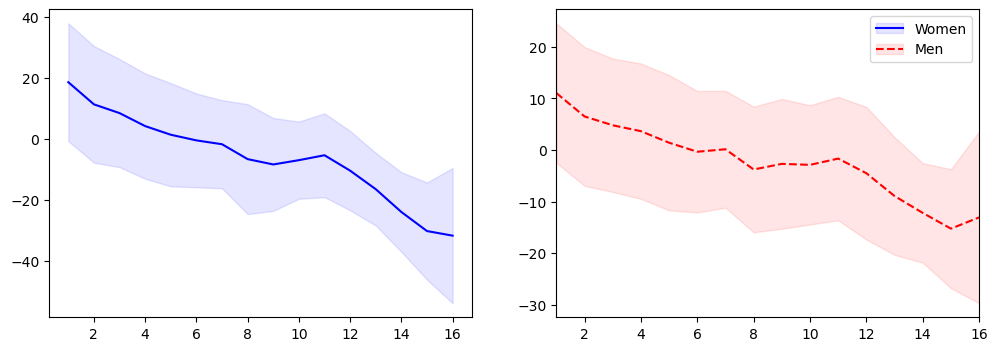

In [17]:
# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

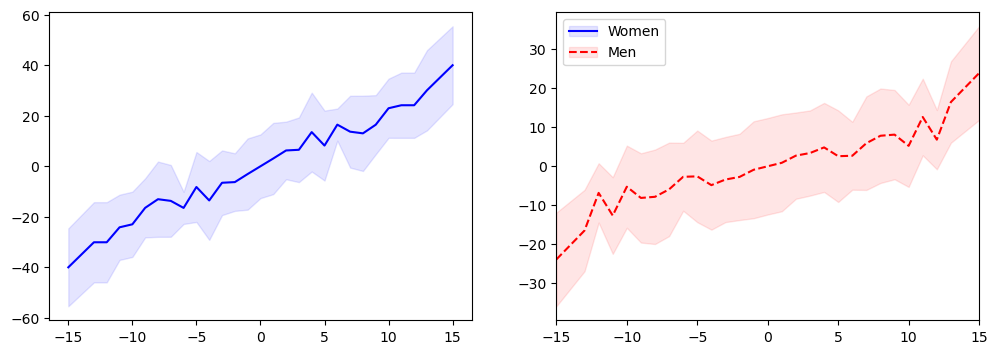

In [18]:
# let's see __seed difference__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## <<- Medium difficulty features ->>

In [19]:
regular_data.columns

Index(['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID', 'T2_Score',
       'NumOT', 'PointDiff', 'win', 'men_women', 'T1_FGM', 'T1_FGA', 'T1_FGM3',
       'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO',
       'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Home', 'T2_FGM', 'T2_FGA', 'T2_FGM3',
       'T2_FGA3', 'T2_FTM', 'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO',
       'T2_Stl', 'T2_Blk', 'T2_PF', 'T2_Home'],
      dtype='object')

In [20]:
# box score columns, for which we want features to our model
boxcols = [
        "T1_Home","T2_Home",
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

In [21]:
set(regular_data.columns.to_list())-set(boxcols)

{'DayNum', 'NumOT', 'Season', 'T1_TeamID', 'T2_TeamID', 'men_women', 'win'}

#### win ratio in past 14 days (only in regular)

##### Results stored into ratio_dict. Will be used later

In [22]:
#Last 14 win ratio

#Return T/F here  to  indicate if win/lose or play/not in last 14 days
regular_data['win14days'] = (regular_data['DayNum'] > 118) & (regular_data['T1_Score'] > regular_data['T2_Score'])
regular_data['win14days'] = regular_data['win14days'].map(int)
regular_data['last14days'] = (regular_data['DayNum'] > 118).map(int)

def summarize_cols(x):
    return pd.Series({
                      'WinRatio14d': x['win14days'].sum() /  (1 + x['last14days'].sum()),
                     })

In [23]:
#Show the winratio of each team in last 14 days
ss_new = regular_data.groupby(['Season','T1_TeamID']).apply(summarize_cols, include_groups=False).reset_index()
ss_new.head()

,Season,T1_TeamID,WinRatio14d
0,2003,1102,0.25
1,2003,1103,0.25
2,2003,1104,0.25
3,2003,1105,0.00
4,2003,1106,0.40


In [24]:
ss_new['WinRatio14d'].unique()

array([0.25      , 0.        , 0.4       , 0.33333333, 0.5       ,
       0.75      , 0.2       , 0.66666667, 0.83333333, 0.6       ,
       0.71428571, 0.8       , 0.42857143, 0.57142857, 0.85714286,
       0.16666667, 0.625     , 0.375     ])

In [25]:
ss_new['season_team'] = ss_new['Season'].map(str) + '_' + ss_new['T1_TeamID'].map(str)
#create a dictionaryu for each team's win ratio in last 14 days
ratio_dict = dict(zip(ss_new['season_team'].tolist(),ss_new['WinRatio14d'].tolist()))
ss_new.head()

,Season,T1_TeamID,WinRatio14d,season_team
0,2003,1102,0.25,2003_1102
1,2003,1103,0.25,2003_1103
2,2003,1104,0.25,2003_1104
3,2003,1105,0.00,2003_1105
4,2003,1106,0.40,2003_1106


In [26]:
#### use d to store match results [win times, lose times] between two teams
#### match_dict uses d to calculate winning odds (if no record, then 1)

In [27]:
s = regular_data['Season'].tolist()
t1 = regular_data['T1_TeamID'].tolist()
t2 = regular_data['T2_TeamID'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()

#Record the results of two games play against each other in total number of [win,lose]
#If two teams have not play any game, assume win/lose are both 1. Prevent infinity caused by divides by 0
d = defaultdict(lambda: [1,1])
for i in range(len(s)):
    tup = str(s[i])+'_'+str(t1[i])+'_'+str(t2[i])
    if s1[i] > s2[i]:
        d[tup][0] += 1
    else:
        d[tup][1] += 1

In [28]:
print(d['2003_1104_1328'])
print(d['2003_1328_1104'])

[2, 1]
[1, 2]


In [29]:
#based on previous matching reuslts, calculate winning odds
match_dict = defaultdict(lambda: 1)
for k,v in d.items():
    match_dict[k] = v[0]/(v[1])
#print(list(match_dict.items()))
print('done')

print(match_dict['2003_1104_1328'])
print(match_dict['2003_1328_1104'])

done
2.0
0.5


In [30]:
### use home_dict to store the numebr of winning games at away in each season
### Second loop may double statistics but no influence on winning prob
#### calculate away_dict using home_dict for winning prob

In [31]:
l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()
h1 = regular_data['T1_Home'].tolist()
h2 = regular_data['T2_Home'].tolist()

In [32]:
#See win/lose of each team at away
#home_dict uses [0,0] is fine since the assuption here is we will have statistics for each team
home_dict = defaultdict(lambda: [0,0]) #1,1])
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]>s2[i] and h1[i] == -1:
        home_dict[k][0]+= 1 #s1[i] #1
    elif s1[i]<s2[i] and h1[i] == -1:
        home_dict[k][1] += 1 #s2[i] #1

for i in range(len(l2)):
    k = str(s0[i])+'_'+str(l2[i])
    if s1[i]<s2[i] and h2[i] == -1:
        home_dict[k][0]+= 1 # s2[i] #1
    elif s1[i]>s2[i] and h2[i] == -1 :
        home_dict[k][1] += 1 #s1[i] #1

#win ratio of each team at away
#maybe should use default dict? If so what default value, 0.5?
away_dict = {}
for k,v in home_dict.items():
    away_dict[k] = v[0]/(v[0]+v[1])
print('done')


done


In [33]:
#See the win/lose statistics of each team in each season [0101..] in l_dict
### Maybe highly correalted to away_win prob
#No need for second loop
#Use l_dict to calcualte awins_dict which records win prob off each team in each season

In [34]:
l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()

#See the win/lose statistics of each team in each season [0101..]
#No need for using for loop in l2 again. Since l1 already contains all info twice. If loop l2 again, each game is recorded 4 times. 
#No influence on win rate, but win times would be doubled

l_dict = defaultdict(list)
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]<s2[i]:
        l_dict[k].append(0)
    else:
        l_dict[k].append(1)
        
# for i in range(len(l2)):
#     k = str(s0[i])+'_'+str(l2[i])
#     if s1[i]>s2[i]:
#         l_dict[k].append(0)
#     else:
#         l_dict[k].append(1)

awins_dict = defaultdict(lambda: np.nan)
for k,v in l_dict.items():
    awins_dict[k] = np.mean(l_dict[k])

In [35]:
#Based on win prob of each team in each season, update fluctuations of team win stats again
#Update awins_dict

#Potential problem here, data are updated using all seasons' stats, should we emphasize closer dates or same season results?
#But in that case, may not have enough data

In [36]:
#对手强度修正
l_dict = defaultdict(list)
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]<s2[i]:
        l_dict[k].append(0) #-(1-awins_dict[str(s0[i])+'_'+str(l2[i])]))
    else:
        l_dict[k].append(awins_dict[str(s0[i])+'_'+str(l2[i])])
        
# for i in range(len(l2)):
#     k = str(s0[i])+'_'+str(l2[i])
#     if s1[i]>s2[i]:
#         l_dict[k].append(0) #-(1-awins_dict[str(s0[i])+'_'+str(l1[i])]))
#     else:
#         l_dict[k].append(awins_dict[str(s0[i])+'_'+str(l1[i])])

awins_dict = defaultdict(lambda: np.nan)
for k,v in l_dict.items():
    awins_dict[k] = np.mean(l_dict[k])

print('done')

done


In [37]:
# calculate averages for boxcolumns (performance) for each team in each season
#After groupby, only box colummns and season and team id, other cols disappear

#Update last 14 days win ratio
#Update 客场胜率
#Update修正完以后得胜率

#Winning odds, not yet
#Seeds difference, not yet

In [38]:
# calculate season averages for boxcolumns (performance)
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

#求平均

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)

#先把他定义为key,之后再update
ss_T1['T1_WinRatio14d'] = ss_T1['Season'].map(str) + '_' + ss_T1['T1_TeamID'].map(str)

#away_dict 客场胜率
ss_T1['T1_away_wins'] = ss_T1['T1_WinRatio14d'].map(away_dict)

#基于对手强度修正的胜率
ss_T1['T1_awins'] = ss_T1['T1_WinRatio14d'].map(awins_dict)

#过去14天胜率 update
#ss_T1['T1_loss_delta'] = ss_T1['T1_WinRatio14d'].map(loss_delta_dict)
ss_T1['T1_WinRatio14d'] = ss_T1['T1_WinRatio14d'].map(ratio_dict)

In [39]:
#Same for T2
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

ss_T2['T2_WinRatio14d'] = ss_T2['Season'].map(str) + '_' + ss_T2['T2_TeamID'].map(str)
ss_T2['T2_away_wins'] = ss_T2['T2_WinRatio14d'].map(away_dict)
ss_T2['T2_awins'] = ss_T2['T2_WinRatio14d'].map(awins_dict)
#ss_T2['T2_loss_delta'] = ss_T2['T2_WinRatio14d'].map(loss_delta_dict)
ss_T2['T2_WinRatio14d'] = ss_T2['T2_WinRatio14d'].map(ratio_dict)

In [40]:
#All the stats above were merged into tourney data, not in regular_data?
#Why?

#Merge winning odds into tourney data

In [41]:
#这样更好因为merge完以后T1是T1，T2是T2，columns不用改名了

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")

#match_dict 是之前算的获胜odds(赔率)，若没有打过，就算1
tourney_data['laplace_matchup'] = tourney_data['Season'].map(str)+'_'+tourney_data['T1_TeamID'].map(str)+'_'+tourney_data['T2_TeamID'].map(str)
tourney_data['laplace_matchup'] = tourney_data['laplace_matchup'].map(match_dict)

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup
0,2003,1421,1411,7.111111,1,1,16,16,0,-0.142857,0.142857,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,0.750000,0.125000,0.174245,0.076923,-0.076923,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,0.714286,0.333333,0.233323,1.000000
1,2003,1112,1436,29.000000,1,1,1,16,15,0.111111,-0.111111,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,0.500000,0.916667,0.488861,-0.166667,0.166667,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,0.750000,0.500000,0.255776,1.000000
2,2003,1113,1272,13.000000,1,1,10,7,-3,0.200000,-0.200000,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,0.500000,0.400000,0.296382,0.185185,-0.185185,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,0.600000,0.636364,0.388420,1.000000
3,2003,1141,1166,6.000000,1,1,11,6,-5,-0.076923,0.076923,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,0.833333,0.642857,0.372517,0.214286,-0.214286,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990,0.800000,0.636364,0.411432,1.000000
4,2003,1143,1301,1.777778,1,1,8,9,1,0.12

In [42]:
#大部分odds都是1 (not informmative)
tourney_data['laplace_matchup'].value_counts()

laplace_matchup
1.000000    4554
0.500000     122
2.000000     122
3.000000       6
0.333333       6
0.250000       3
4.000000       3
1.500000       2
0.666667       2
Name: count, dtype: int64

In [43]:
#So previously, most odds are 2, 0.5, 1, 3, and 0.3. Sort of informative

from collections import Counter
Counter(match_dict.values())

Counter({2.0: 90911,
         0.5: 90911,
         1.0: 36804,
         3.0: 26847,
         0.3333333333333333: 26847,
         1.5: 4400,
         0.6666666666666666: 4400,
         4.0: 3408,
         0.25: 3408,
         5.0: 27,
         0.2: 27,
         2.5: 7,
         0.4: 7,
         6.0: 2,
         0.16666666666666666: 2,
         1.6666666666666667: 1,
         0.6: 1})

In [44]:
#Stats here are in each season
pd.DataFrame(list(match_dict.items()), columns=["key","value"])

,key,value
0,2003_1104_1328,2.0
1,2003_1272_1393,2.0
2,2003_1266_1437,2.0
3,2003_1296_1457,2.0
4,2003_1400_1208,2.0
...,...,...
288005,2025_3328_3163,1.0
288006,2025_3243_3425,1.0
288007,2025_3261_3417,1.0
288008,2025_3395_3400,1.0


In [45]:
tourney_data[tourney_data['laplace_matchup']==4]

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup
3981,2011,3124,3401,-12.0,0,0,1,2,1,0.357143,-0.357143,80.060606,28.242424,59.666667,5.242424,13.363636,18.333333,24.666667,14.636364,30.333333,16.878788,14.000000,7.969697,7.121212,13.090909,53.696970,19.848485,61.878788,5.303030,20.393939,8.696970,12.454545,13.757576,20.606061,8.909091,16.515152,5.727273,2.666667,20.484848,26.363636,0.833333,0.777778,0.563800,0.043478,-0.043478,78.633333,29.466667,65.100000,4.900000,14.333333,14.800000,20.333333,16.433333,23.133333,16.666667,14.033333,10.833333,4.200000,18.566667,58.266667,19.800000,51.133333,4.500000,14.233333,14.166667,19.800000,11.100000,21.966667,10.100000,22.533333,5.700000,4.133333,18.566667,20.366667,0.5,0.727273,0.494500,4.0
3982,2011,3163,3323,-9.0,0,0,1,2,1,0.250000,-0.250000,77.696970,28.787879,57.424242,5.969697,16.575758,14.151515,18.393939,12.575758,29.606061,19.484848,15.333333,9.151515,4.424242,12.424242,49.969697,18.606061,57.909091,5.030303,18.151515,7.727273,11.272727,11.090909,18.363636,10.242424,16.727273,6.696970,2.696970,16.696970,27.727273,0.800000,0.916667,0.598230,0.172414,-0.172414,77.284848,28.339394,58.975758,3.333333,9.606061,17.272727,24.006061,15.193939,25.666667,17.181818,17.654545,13.206061,4.442424,16.521212,54.751515,19.909091,55.006061,4.127273,15.787879,10.806061,16.296970,12.678788,19.072727,11.127273,22.812121,8.454545,2.896970,18.781818,22.533333,0.4,0.583333,0.409741,4.0
4108,2013,3323,3163,-18.0,0,0,1,1,0,0.120000,-0.120000,79.765152,28.989899,63.380366,4.140783,12.394255,17.644571,22.138573,16.472222,26.724747,19.043876,15.425189,10.773359,3.847538,13.722222,56.761995,21.413194,58.165720,4.395202,15.145518,9.540404,13.282828,12.049242,20.311237,12.432449,20.333649,8.519886,4.376263,18.262942,23.003157,0.800000,1.000000,0.566021,0.185185,-0.185185,81.129477,30.696970,62.473829,8.487603,22.683196,11.247934,14.977961,13.876033,28.793388,20.567493,14.074380,10.382920,5.782369,12.746556,48.691460,17.953168,57.052342,4.688705,16.264463,8.096419,12.046832,11.787879,19.595041,10.278237,18.826446,6.079890,1.741047,14.969697,32.438017,0.4,0.909091,0.513664,4.0


In [46]:
regular_data[(regular_data['Season']==2013) & (regular_data['T1_TeamID']==3323) & (regular_data['T2_TeamID']==3163) ]

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home,win14days,last14days
136234,2013,61,3323,73.000000,3163,72.000000,0,1.000000,1,0,25.000000,66.000000,6.000000,12.000000,17.000000,24.000000,18.0,27.000000,12.000000,14.000000,4.000000,4.000000,16.0,-1.0,28.0,71.000000,5.000000,23.000000,11.000000,14.000000,17.000000,27.000000,21.000000,14.000000,8.000000,9.000000,17.000000,1.0,0,0
138847,2013,119,3323,69.818182,3163,63.272727,3,6.545455,1,0,25.454545,64.727273,0.727273,8.727273,18.181818,22.545455,16.0,19.636364,10.181818,15.272727,11.636364,1.454545,16.0,1.0,24.0,51.636364,5.090909,14.545455,10.181818,15.272727,10.909091,26.181818,16.727273,25.454545,11.636364,5.818182,19.636364,-1.0,1,1
139135,2013,127,3323,61.000000,3163,59.000000,0,2.000000,1,0,26.000000,63.000000,3.000000,12.000000,6.000000,6.000000,12.0,21.000000,14.000000,13.000000,6.000000,3.000000,13.0,NaN,25.0,57.000000,0.000000,5.000000,9.000000,11.000000,11.000000,25.000000,11.000000,17.000000,5.000000,2.000000,14.000000,NaN,1,1


## <<- Hard difficulty features ->>

In [47]:
#Find best K for elo
def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

def update_elo(winner_elo, loser_elo,k_factor):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


base_elo = 1000
elo_width = 400
#k_factor = 100


def elo_fill(k):
    elos = []
    for season in sorted(set(seeds["Season"])):
        ss = regular_data.loc[regular_data["Season"] == season]
        ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
        teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
        elo = dict(zip(teams, [base_elo] * len(teams)))
        for i in range(ss.shape[0]):
            w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
            w_elo, l_elo = elo[w_team], elo[l_team]
            w_elo_new, l_elo_new = update_elo(w_elo, l_elo, k)
            elo[w_team] = w_elo_new
            elo[l_team] = l_elo_new
        elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
        elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
        elo["Season"] = season
        elos.append(elo)
    elos = pd.concat(elos)
    return elos

In [48]:
#Find best K for ELO
# loss_dict={}

# for k in range(40,161,10):
#     tourney_copy=tourney_data.copy()
#     test=elo_fill(k)
    
#     elos_T1 = test.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
#     elos_T2 = test.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
    
#     tourney_copy = pd.merge(tourney_copy, elos_T1, on=["Season", "T1_TeamID"], how="left")
#     tourney_copy = pd.merge(tourney_copy, elos_T2, on=["Season", "T2_TeamID"], how="left")
    
#     #tourney_copy["elo_diff"] = tourney_copy["T1_elo"] - tourney_copy["T2_elo"]
#     tourney_copy["expect"] = expected_result(tourney_copy["T1_elo"], tourney_copy["T2_elo"])
    
#     season_loss=[]

#     for season in tourney_copy['Season'].unique().tolist():
#         sub=tourney_copy[(tourney_copy['Season']==season) & (tourney_copy['win']==1)]
#         season_loss.append(((sub["expect"] - 1) ** 2).mean())
        
#     loss_dict[k] = float(np.mean(season_loss))

In [49]:
# tourney_copy=tourney_data.copy()
# tourney_copy=tourney_copy.drop(['T1_elo', 'T2_elo'], axis=1)
# test=elo_fill(80)

# loss_dict={}
# elos_T1 = test.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
# elos_T2 = test.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)

# tourney_copy = pd.merge(tourney_copy, elos_T1, on=["Season", "T1_TeamID"], how="left")
# tourney_copy = pd.merge(tourney_copy, elos_T2, on=["Season", "T2_TeamID"], how="left")

# #tourney_copy["elo_diff"] = tourney_copy["T1_elo"] - tourney_copy["T2_elo"]
# tourney_copy["expect"] = expected_result(tourney_copy["T1_elo"], tourney_copy["T2_elo"])

# season_loss=[]

# for season in tourney_copy['Season'].unique().tolist():
#     sub=tourney_copy[(tourney_copy['Season']==season) & (tourney_copy['win']==1)]
#     season_loss.append(((sub["expect"] - 1) ** 2).mean())
    
# loss_dict[k] = float(np.mean(season_loss))

In [50]:
# season_loss

In [51]:
# loss_df = pd.DataFrame(
#     [{"k_factor": k, "mean_loss": v} for k, v in loss_dict.items()]
# ).sort_values("mean_loss", ascending=True).reset_index(drop=True)

# print(loss_df)

# best_k = int(loss_df.loc[0, "k_factor"])
# best_loss = float(loss_df.loc[0, "mean_loss"])
# print("best_k:", best_k)
# print("best_loss:", best_loss)

# plot_df = loss_df.sort_values("k_factor")
# plt.figure()
# plt.plot(plot_df["k_factor"], plot_df["mean_loss"], marker="o")
# plt.xlabel("k_factor")
# plt.ylabel("mean_loss")
# plt.title("Mean loss vs K")
# plt.grid(True)
# plt.show()

In [52]:
base_elo = 1000
elo_width = 400
k_factor = 80

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    #Only focus on win==1 to calculate every match once
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo,80)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
elos = pd.concat(elos)

In [53]:
#Merge ELO back to tourney_data

In [54]:
elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

In [55]:
#Make sense that team make to tourney has higher ELO

<Axes: xlabel='elo'>

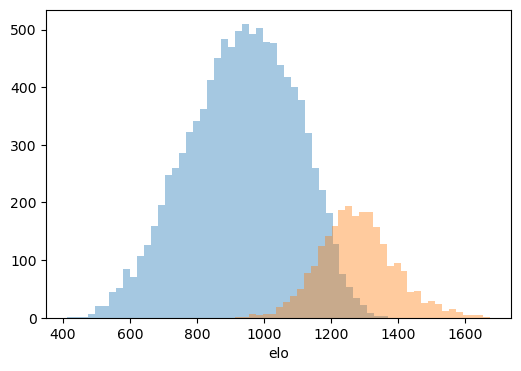

In [56]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

In [57]:
#Make sense, lower the seed, higher the ELO
#But seems only work on extreme cases: seed 1, 2, 3, 16

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

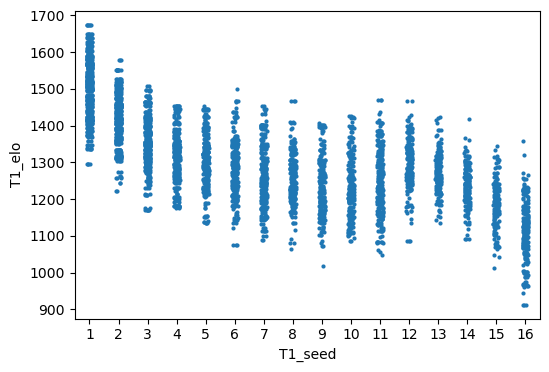

In [58]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

In [59]:
# Larger seed diff, larger ELO diff, make sense
#Larger seed diff and ELO diff, more chance in winning



<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

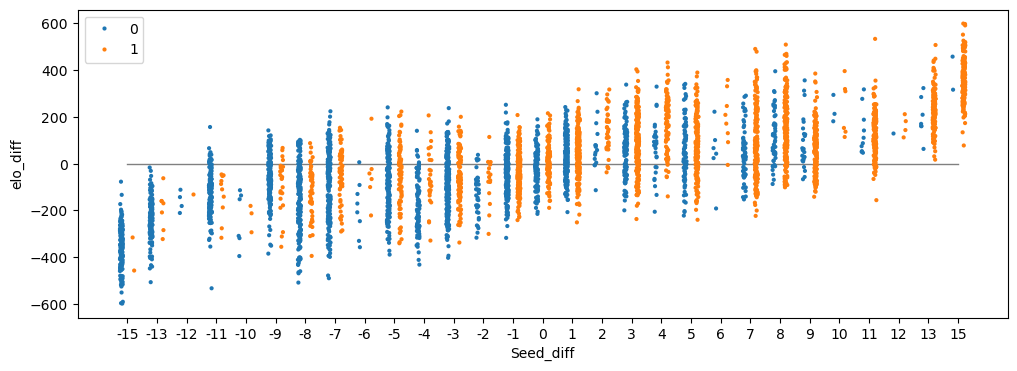

In [60]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

## <<- Hardest difficulty features ->>

In [61]:
#Try to see if can use 

In [62]:
regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)


In [63]:
seeds_T1

,Season,T1_TeamID,T1_seed,ST1
1154,2003,1328,1,2003/1328
1155,2003,1448,2,2003/1448
1156,2003,1393,3,2003/1393
1157,2003,1257,4,2003/1257
1158,2003,1280,5,2003/1280
...,...,...,...,...
1739,2025,3193,12,2025/3193
1740,2025,3251,13,2025/3251
1741,2025,3195,14,2025/3195
1742,2025,3117,15,2025/3117


In [64]:
seeds_T2

,Season,T2_TeamID,T2_seed,ST2
1154,2003,1328,1,2003/1328
1155,2003,1448,2,2003/1448
1156,2003,1393,3,2003/1393
1157,2003,1257,4,2003/1257
1158,2003,1280,5,2003/1280
...,...,...,...,...
1739,2025,3193,12,2025/3193
1740,2025,3251,13,2025/3251
1741,2025,3195,14,2025/3195
1742,2025,3117,15,2025/3117


In [65]:
print(len(seeds_T1["ST1"]))
print(len(set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])))

2896
2896


In [66]:
import statsmodels.api as sm
# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

## st is the season/team_id for all teams made into tourney or beated teams went to tourney

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        #for this season and for men/women, run the regression over dt df
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

#Find the rows of those match records of teams went into tourney or beated tourney teams
dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
#For those teams not went into tourney/not beat tourney teams, overwrite id into 0000
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))

#Run regression of team id to predict point diff
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

100%|██████████| 22/22 [01:35<00:00,  4.33s/season]


In [67]:
glm_quality

,TeamID,quality,Season
0,0,2.142730e-14,2003
1,1102,1.016058e+01,2003
2,1103,3.540853e+00,2003
3,1104,2.014129e+01,2003
4,1105,-4.081386e+00,2003
...,...,...,...
7796,1473,-2.599197e+00,2025
7797,1474,4.698754e+00,2025
7798,1475,-4.384087e+00,2025
7799,1476,-1.966107e+00,2025


<Axes: ylabel='T1_quality'>

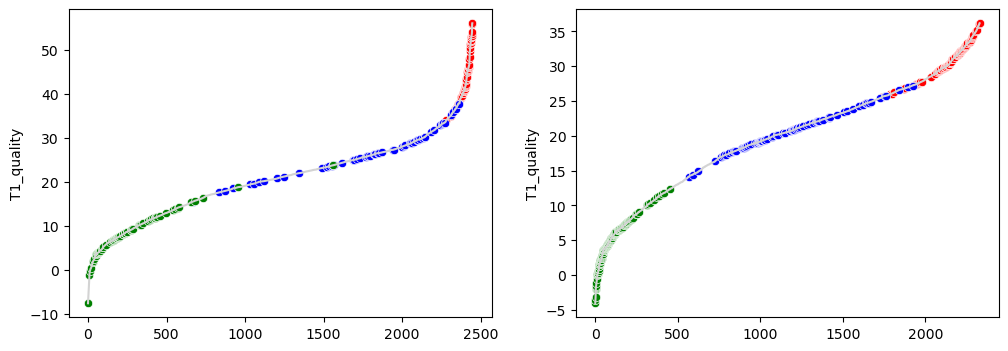

In [68]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])


In [69]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


In [70]:
print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [71]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


## ML

In [72]:
regular_data

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home,win14days,last14days,ST1,ST2
0,2003,10,1104,68.0,1328,62.0,0,6.0,1,1,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,NaN,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,NaN,0,0,2003/1104,2003/1328
1,2003,10,1272,70.0,1393,63.0,0,7.0,1,1,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,NaN,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,NaN,0,0,2003/1272,2003/1393
2,2003,11,1266,73.0,1437,61.0,0,12.0,1,1,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,NaN,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,NaN,0,0,2003/1266,2003/1437
3,2003,11,1296,56.0,1457,50.0,0,6.0,1,1,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,NaN,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,NaN,0,0,2003/1296,2003/1457
4,2003,11,1400,77.0,1208,71.0,0,6.0,1,1,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,NaN,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,NaN,0,0,2003/1400,2003/1208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401175,2025,131,3413,66.0,3471,75.0,0,-9.0,0,0,24.0,67.0,9.0,29.0,9.0,14.0,9.0,26.0,14.0,10.0,6.0,5.0,22.0,1.0,26.0,62.0,4.0,19.0,19.0,28.0,8.0,31.0,10.0,11.0,6.0,1.0,20.0,-1.0,0,1,2025/3413,2025/3471
401176,2025,132,3476,49.0,3192,66.0,0,-17.0,0,0,21.0,57.0,4.0,20.0,3.0,4.0,14.0,22.0,14.0,17.0,4.0,1.0,17.0,-1.0,23.0,55.0,3.0,21.0,17.0,18.0,10.0,22.0,11.0,9.0,8.0,1.0,8.0,1.0,0,1,2025/3476,2025/3192
401177,2025,132,3119,62.0,3250,74.0,0,-12.0,0,0,25.0,56.0,6.0,17.0,6.0,10.0,8.0,13.0,10.0,10.0,5.0,0.0,20.0,-1.0,27.0,45.0,5.0,14.0,15.0,17.0,5.0,25.0,15.0,15.0,6.0,0.0,12.0,1.0,0,1,2025/3119,2025/3250
401178,2025,132,3125,62.0,3293,83.0,0,-21.0,0,0,24.0,68.0,2.0,21.0,12.0,14.0,12.0,22.0,11.0,7.0,5.0,0.0,16.0,NaN,28.0,54.0,14.0,28.0,13.0,15.0,5.0,33.0,21.0,13.0,2.0,3.0,15.0,NaN,0,1,2025/3125,2025/3293


In [73]:
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup,T1_elo,T2_elo,elo_diff,T1_quality,T2_quality,diff_quality
0,2003,1421,1411,7.111111,1,1,16,16,0,-0.142857,0.142857,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,0.750000,0.125000,0.174245,0.076923,-0.076923,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,0.714286,0.333333,0.233323,1.000000,994.763477,1003.140568,-8.377090,-3.099741,2.115495,-5.215236
1,2003,1112,1436,29.000000,1,1,1,16,15,0.111111,-0.111111,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,0.500000,0.916667,0.488861,-0.166667,0.166667,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,0.750000,0.500000,0.255776,1.000000,1387.057304,1143.093901,243.963403,27.707625,8.728406,18.979218
2,2003,1113,1272,13.000000,1,1,10,7,-3,0.200000,-0.200000,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,0.500000,0.400000,0.296382,0.185185,-0.185185,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,0.600000,0.636364,0.388420,1.000000,1152.263291,1310.981377,-158.718086,19.701429,19.004846,0.696583
3,2003,1141,1166,6.000000,1,1,11,6,-5,-0.076923,0.076923,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,0.833333,0.642857,0.372517,0.214286,-0.214286,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.

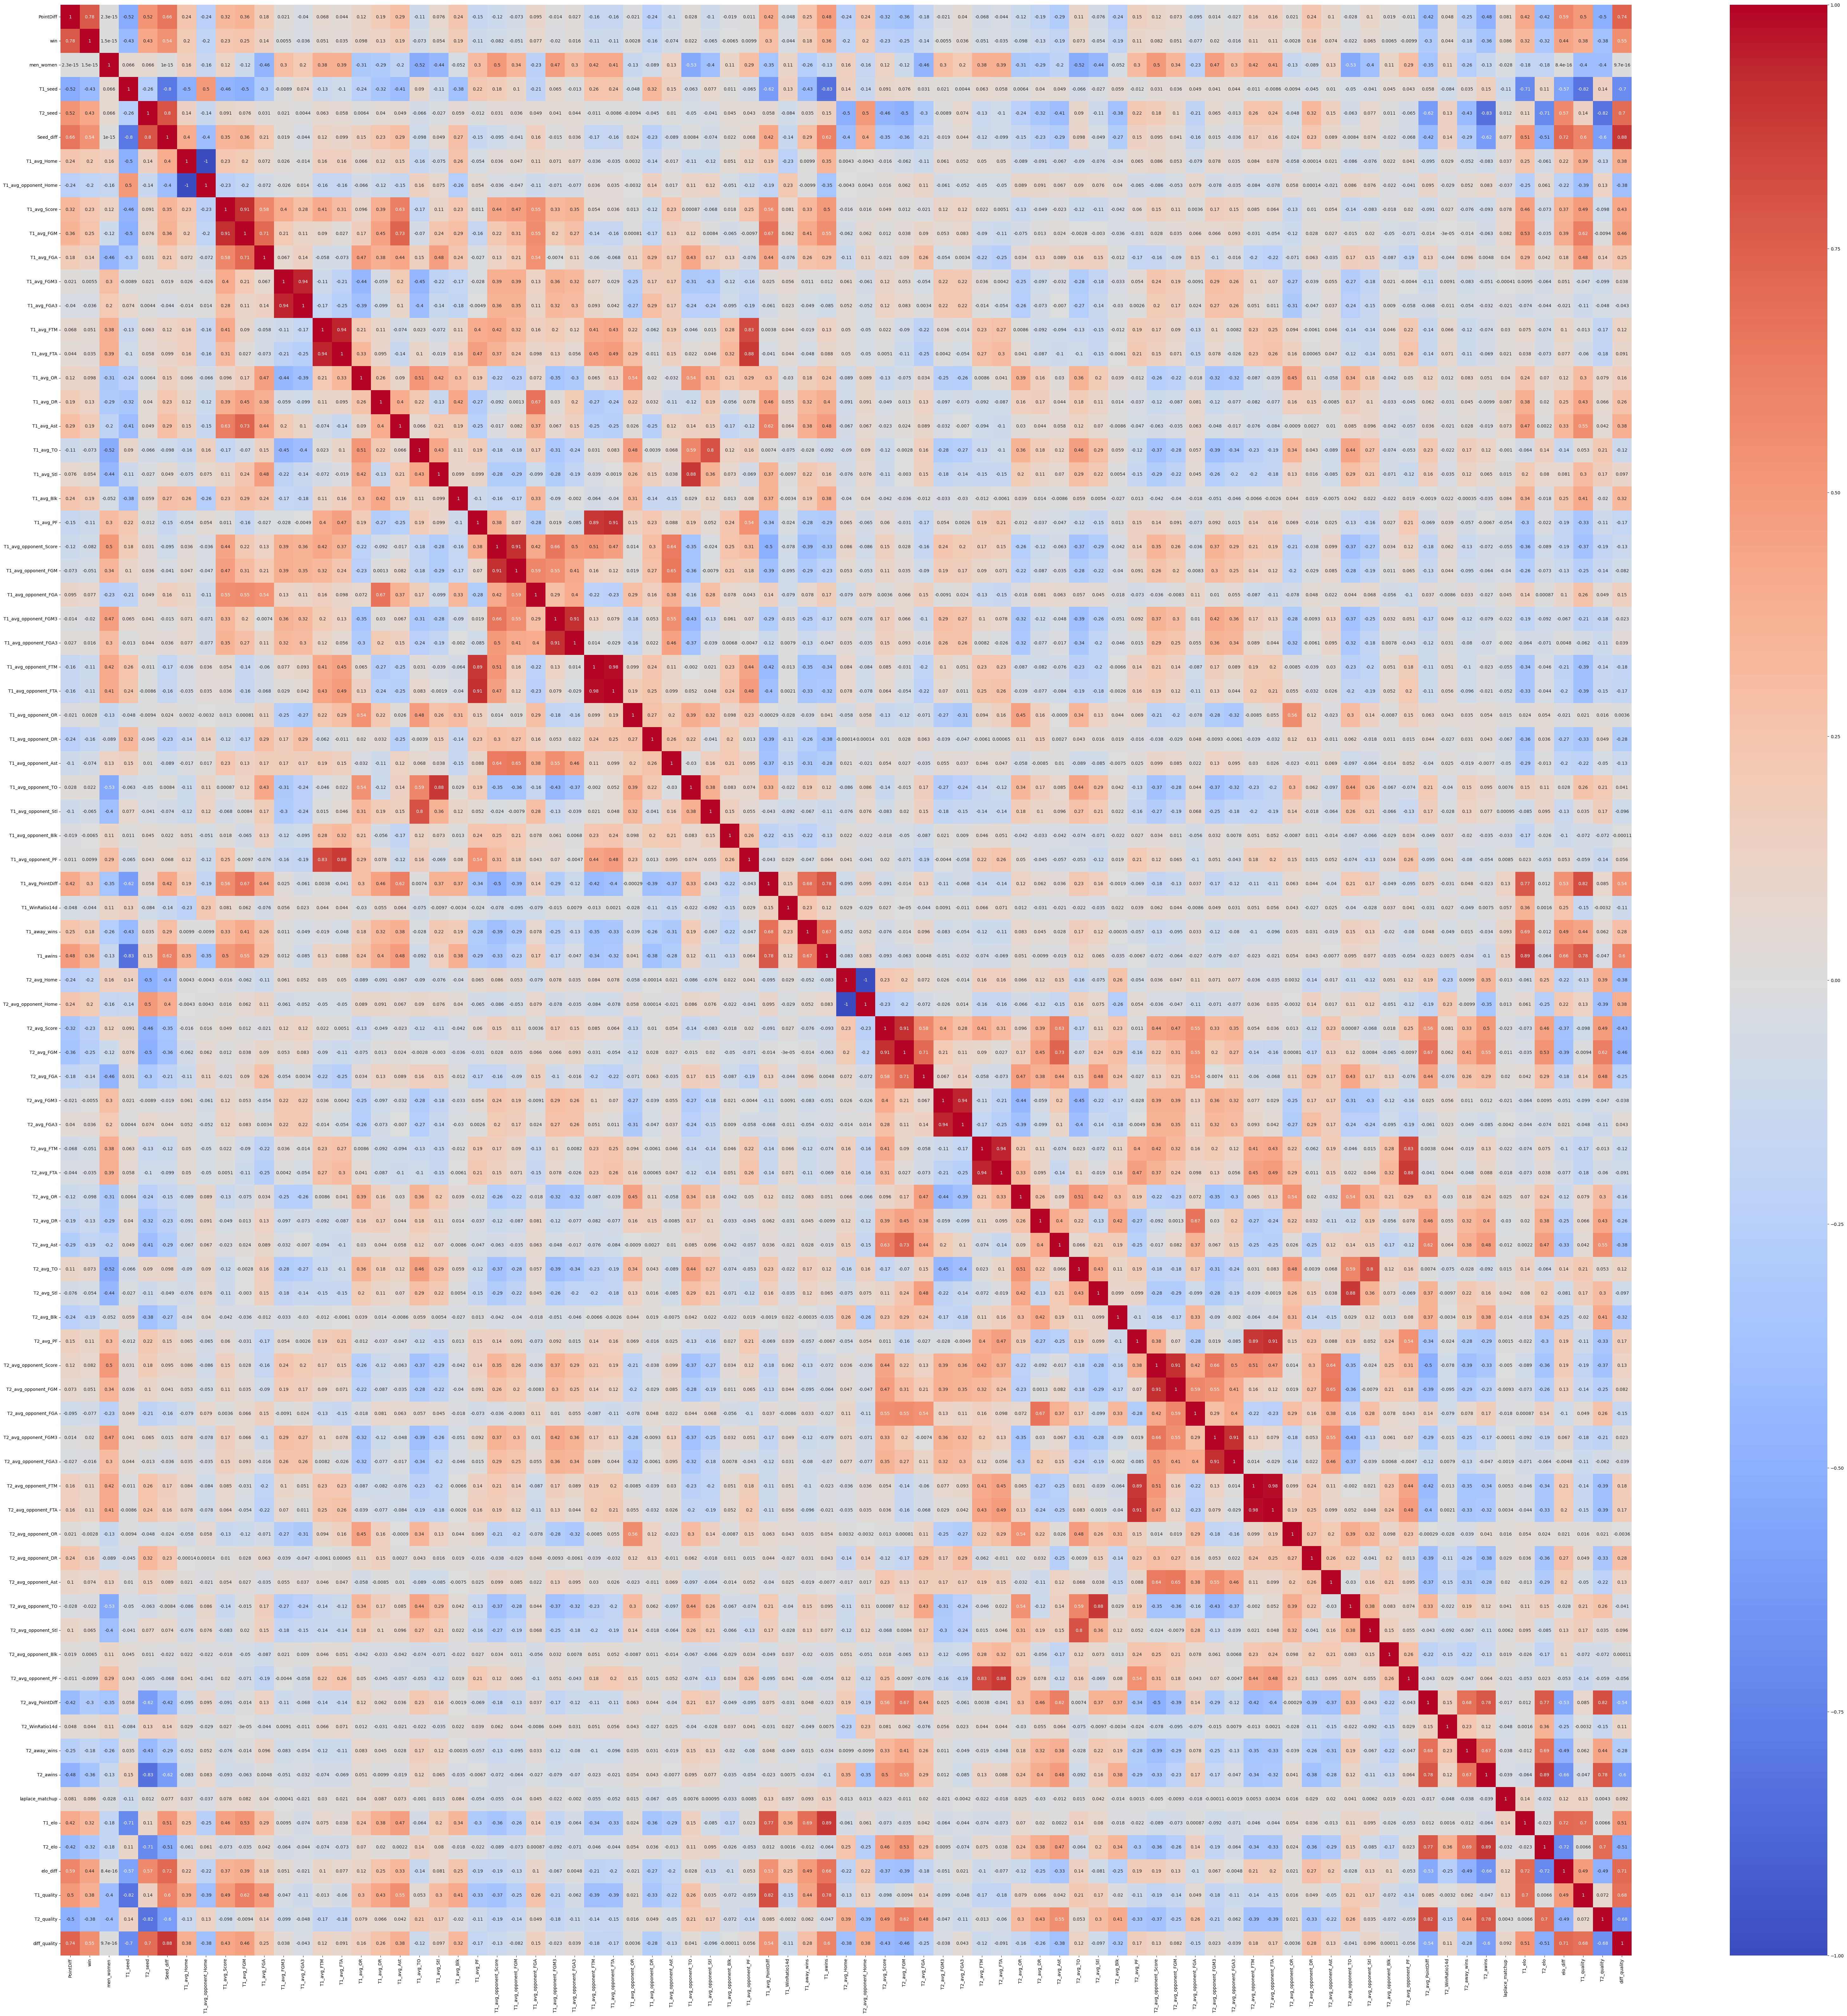

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = tourney_data.drop(columns=['Season','T1_TeamID','T2_TeamID']).corr()

plt.figure(figsize=(80,80))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

In [75]:
with pd.ExcelWriter("correlation_matrix.xlsx", engine="xlsxwriter") as writer:
    
    corr.to_excel(writer, sheet_name="Correlation")
    
    workbook  = writer.book
    worksheet = writer.sheets["Correlation"]
    
    rows, cols = corr.shape

    worksheet.conditional_format(
    1, 1, rows, cols,
    {
        "type": "3_color_scale",
        "min_color": "#3B4CC0",
        "mid_color": "#FFFFFF",
        "max_color": "#B40426",
    }
)

In [76]:
cat_features = [
    "T1_avg_FGM",
    "T1_avg_FGM3",
    "T1_avg_FGA3",
    "T1_avg_FTM",
    "T1_avg_FTA",
    "T1_avg_OR",
    "T1_avg_DR",
    "T1_avg_Ast",
    "T1_avg_TO",
    "T1_avg_Stl",
    "T1_avg_opponent_Score",
    "T1_avg_opponent_FGM",
    "T1_avg_opponent_FGM3",
    "T1_avg_opponent_FGA3",
    "T1_avg_opponent_FTM",
    "T1_avg_opponent_FTA",
    "T1_avg_opponent_OR",
    "T1_avg_opponent_DR",
    "T1_avg_opponent_Ast",
    "T1_avg_opponent_TO",
    "T1_avg_opponent_Stl",
    "T2_avg_FGM",
    "T2_avg_FGM3",
    "T2_avg_FGA3",
    "T2_avg_FTM",
    "T2_avg_FTA",
    "T2_avg_OR",
    "T2_avg_DR",
    "T2_avg_Ast",
    "T2_avg_TO",
    "T2_avg_Stl",
    "T2_avg_opponent_Score",
    "T2_avg_opponent_FGM",
    "T2_avg_opponent_FGM3",
    "T2_avg_opponent_FGA3",
    "T2_avg_opponent_FTM",
    "T2_avg_opponent_FTA",
    "T2_avg_opponent_OR",
    "T2_avg_opponent_DR",
    "T2_avg_opponent_Ast",
    "T2_avg_opponent_TO",
    "T2_avg_opponent_Stl",    
]

len(cat_features)

42

In [77]:
np.random.seed(0)
cb_model1a = make_pipeline(StandardScaler(), NuSVC(probability=True, nu = 0.6, kernel = 'poly', gamma='scale', degree=2))
cb_model1b = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=100, weights='uniform', p=2, metric='minkowski'))

#Train with men, predict women
x_train = tourney_data.loc[tourney_data[ "men_women"] == 1, cat_features].values
y_train = tourney_data.loc[tourney_data[ "men_women"] == 1, "PointDiff"].values
#Predict win or  not by use (y_train > 0) *1.0
y_train1 = (y_train > 0) *1.0
#NUSVC for classification
cb_model1a.fit(x_train, y_train1)
#KNN  for regression
cb_model1b.fit(x_train, y_train)

x_test = tourney_data.loc[tourney_data[ "men_women"] != 1, cat_features].values

preds1a = cb_model1a.predict_proba(x_test)[:,1]
preds1b = cb_model1b.predict(x_test)
###################################


cb_model2a = make_pipeline(StandardScaler(), NuSVC(probability=True, nu = 0.6, kernel = 'poly', gamma='scale', degree=2))
cb_model2b = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=100, weights='uniform', p=2, metric='minkowski'))

#Train with women, predict men
x_train = tourney_data.loc[tourney_data[ "men_women"] != 1, cat_features].values
y_train = tourney_data.loc[tourney_data[ "men_women"] != 1, "PointDiff"].values
y_train2 = (y_train > 0) *1.0
#NUSVC for classification
cb_model2a.fit(x_train, y_train2)
#KNN  for regression
cb_model2b.fit(x_train, y_train)

x_test = tourney_data.loc[tourney_data[ "men_women"] == 1, cat_features].values

preds2a = cb_model2a.predict_proba(x_test)[:,1]
preds2b = cb_model2b.predict(x_test)

In [78]:
y_test = tourney_data.loc[tourney_data[ "men_women"] != 1, "PointDiff"].values
y_test = (y_test > 0) *1.0

brier = brier_score_loss(y_test, preds1a)
brier

np.float64(0.2541777804984798)

In [79]:
y_test = tourney_data.loc[tourney_data[ "men_women"] == 1, "PointDiff"].values
y_test = (y_test > 0) *1.0

brier = brier_score_loss(y_test, preds2a)
brier

np.float64(0.2701197129538707)

In [80]:
#Almost no predictive power  since symmetric data

tourney_data['cb_preds1'] = np.nan
#model a for classification
tourney_data.loc[tourney_data[ "men_women"] == 1, 'cb_preds1'] = preds2a
tourney_data.loc[tourney_data[ "men_women"] != 1, 'cb_preds1'] = preds1a
tourney_data['cb_preds1'].describe()

count    4820.000000
mean        0.499673
std         0.117146
min         0.074725
25%         0.429402
50%         0.500000
75%         0.568435
max         0.924395
Name: cb_preds1, dtype: float64

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_test = tourney_data.loc[tourney_data[ "men_women"] != 1, "PointDiff"].values
# y_test = (y_test > 0) *1.0

mse = mean_squared_error(y_test, preds1b)
mse

380.1231476290901

In [82]:
y_test = tourney_data.loc[tourney_data[ "men_women"] == 1, "PointDiff"].values
# y_test = (y_test > 0) *1.0

mse = mean_squared_error(y_test, preds2b)
mse

182.7068841697552

In [83]:
#results of mean since data is symmetric

tourney_data['cb_preds2'] = np.nan
#model 2 for point diff regression
tourney_data.loc[tourney_data[ "men_women"] == 1, 'cb_preds2'] = preds2b
tourney_data.loc[tourney_data[ "men_women"] != 1, 'cb_preds2'] = preds1b
tourney_data['cb_preds2'].describe()

count    4820.000000
mean        0.000000
std         3.761162
min       -14.189556
25%        -2.358222
50%         0.000000
75%         2.358222
max        14.189556
Name: cb_preds2, dtype: float64

In [84]:
features = [
    ### EASY FEATURES ###
    "men_women",    
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    "T1_avg_FGA",
    "T1_awins", "T2_awins",
    "T1_away_wins","T2_away_wins",
    "laplace_matchup",
    "T1_WinRatio14d",
    "T2_WinRatio14d",
    "cb_preds1","cb_preds2",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGA",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",    
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
]

print(f"Number of features {len(features)}")

Number of features 34


In [85]:
features = [
    ### EASY FEATURES ###
    "men_women",    
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    "T1_avg_FGA",
    "T1_awins", "T2_awins",
    "T1_away_wins","T2_away_wins",
    "laplace_matchup",
    "T1_WinRatio14d",
    "T2_WinRatio14d",
    "cb_preds1","cb_preds2",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGA",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",    
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
]

print(f"Number of features {len(features)}")

Number of features 34


In [86]:

param = {}
param["objective"] = "reg:squarederror"
param["booster"] = "gbtree"
param["eta"] = 0.01
param["subsample"] = 0.6
param["colsample_bynode"] = 0.8
param["num_parallel_tree"] = 2
param["min_child_weight"] = 4
param["max_depth"] = 4
param["tree_method"] = "hist"
param['grow_policy'] = 'lossguide'
param["max_bin"] = 32

num_rounds = 700

def cauchyobj(preds, dtrain): 
  labels = dtrain.get_label()
  c = 5000 
  x =  preds-labels
  x2 = x**2
  c2 = c**2
  grad = x / (x2/c2+1)
  hess = -c2*(x2-c2)/(x2+c2)**2
  return grad, hess



xgb_parameters = {
    'eval_metric': 'mae',
    'eta': 0.02,
    'subsample': 0.35,
    'colsample_bytree': 0.7,
    'num_parallel_tree': 10,
    'min_child_weight': 40,
    'max_depth': 4, #worse at both 3,5,
    'gamma': 10,
}

In [89]:
models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)

    models[oof_season] = xgb.train(
      params = xgb_parameters,
      dtrain = dtrain,
      num_boost_round = 400, 
      obj = cauchyobj,
    )
    
    preds = models[oof_season].predict(dval)
    tourney_data.loc[tourney_data["Season"] == oof_season, "pred_margin"] = preds
    
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"average mae: {np.mean(oof_mae)}")

oof season 2003 mae: 8.799202173765904
oof season 2004 mae: 7.891787370179534
oof season 2005 mae: 7.770463792946087
oof season 2006 mae: 8.378763114764459
oof season 2007 mae: 7.6393498418493735
oof season 2008 mae: 9.706558542265864
oof season 2009 mae: 9.365325777241054
oof season 2010 mae: 8.649654131201492
oof season 2011 mae: 9.581200175355946
oof season 2012 mae: 8.331483640645144
oof season 2013 mae: 9.886894367303476
oof season 2014 mae: 9.90641582301603
oof season 2015 mae: 8.04618064172757
oof season 2016 mae: 10.136013333985312
oof season 2017 mae: 9.998842722620482
oof season 2018 mae: 10.259080663756427
oof season 2019 mae: 8.977257389562507
oof season 2021 mae: 10.34099163562637
oof season 2022 mae: 10.374991612974709
oof season 2023 mae: 9.409975551859558
oof season 2024 mae: 9.385416264666606
oof season 2025 mae: 9.882377099791297
average mae: 9.214464803050236


In [90]:
### Logistic
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# 假设你已经有这三列
# tourney_data["pred_margin"]
# tourney_data["win"]
# tourney_data["Season"]

logistic_oof_prob = np.full(len(tourney_data), np.nan)
brier_list = []
logistic_models = {}

for oof_season in sorted(tourney_data["Season"].unique()):
    
    train_idx = tourney_data["Season"] != oof_season
    val_idx = tourney_data["Season"] == oof_season
    
    x_train = tourney_data.loc[train_idx, "pred_margin"].values.reshape(-1, 1)
    y_train = tourney_data.loc[train_idx, "win"].values
    
    x_val = tourney_data.loc[val_idx, "pred_margin"].values.reshape(-1, 1)
    y_val = tourney_data.loc[val_idx, "win"].values
    
    log_model = LogisticRegression(solver="liblinear", random_state=0, max_iter=300)
    log_model.fit(x_train, y_train)
    
    logistic_models[oof_season] = log_model
    
    prob_val = log_model.predict_proba(x_val)[:, 1]
    prob_val = np.clip(prob_val, 0.01, 0.99)
    
    logistic_oof_prob[val_idx] = prob_val
    
    brier = brier_score_loss(y_val, prob_val)
    brier_list.append(brier)
    
    print(f"season {oof_season} logistic brier: {brier:.6f}")

print("Average logistic brier:", np.mean(brier_list))

season 2003 logistic brier: 0.181460
season 2004 logistic brier: 0.170803
season 2005 logistic brier: 0.166665
season 2006 logistic brier: 0.189866
season 2007 logistic brier: 0.140923
season 2008 logistic brier: 0.154587
season 2009 logistic brier: 0.166692
season 2010 logistic brier: 0.165924
season 2011 logistic brier: 0.179780
season 2012 logistic brier: 0.154935
season 2013 logistic brier: 0.170320
season 2014 logistic brier: 0.174112
season 2015 logistic brier: 0.143362
season 2016 logistic brier: 0.175330
season 2017 logistic brier: 0.157924
season 2018 logistic brier: 0.178860
season 2019 logistic brier: 0.142454
season 2021 logistic brier: 0.178639
season 2022 logistic brier: 0.186205
season 2023 logistic brier: 0.182812
season 2024 logistic brier: 0.153540
season 2025 logistic brier: 0.120531
Average logistic brier: 0.16526010078717682


In [91]:
### CDF

from scipy.stats import norm
from sklearn.metrics import brier_score_loss
import numpy as np

cdf_oof_prob = np.full(len(tourney_data), np.nan)
brier_list = []

for oof_season in sorted(tourney_data["Season"].unique()):
    
    train_idx = tourney_data["Season"] != oof_season
    val_idx = tourney_data["Season"] == oof_season
    
    # train data
    pred_train = tourney_data.loc[train_idx, "pred_margin"].values
    diff_train = tourney_data.loc[train_idx, "PointDiff"].values
    
    # residual std
    residual = diff_train - pred_train
    sigma = np.std(residual)
    
    # validation predictions
    pred_val = tourney_data.loc[val_idx, "pred_margin"].values
    y_val = tourney_data.loc[val_idx, "win"].values
    
    prob_val = norm.cdf(pred_val / sigma)
    prob_val = np.clip(prob_val, 0.01, 0.99)
    
    cdf_oof_prob[val_idx] = prob_val
    
    brier = brier_score_loss(y_val, prob_val)
    brier_list.append(brier)
    
    print(f"season {oof_season} cdf brier: {brier:.6f}")

print("Average CDF brier:", np.mean(brier_list))

season 2003 cdf brier: 0.180997
season 2004 cdf brier: 0.172511
season 2005 cdf brier: 0.167874
season 2006 cdf brier: 0.189564
season 2007 cdf brier: 0.144415
season 2008 cdf brier: 0.156599
season 2009 cdf brier: 0.166859
season 2010 cdf brier: 0.165232
season 2011 cdf brier: 0.177230
season 2012 cdf brier: 0.156599
season 2013 cdf brier: 0.170528
season 2014 cdf brier: 0.173002
season 2015 cdf brier: 0.145310
season 2016 cdf brier: 0.174922
season 2017 cdf brier: 0.158429
season 2018 cdf brier: 0.177334
season 2019 cdf brier: 0.142333
season 2021 cdf brier: 0.176552
season 2022 cdf brier: 0.184723
season 2023 cdf brier: 0.182543
season 2024 cdf brier: 0.154019
season 2025 cdf brier: 0.122677
Average CDF brier: 0.1654659330018282


In [92]:
#Spline

import numpy as np
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import brier_score_loss

spline_oof_prob = np.full(len(tourney_data), np.nan)
brier_list = []
spline_models = {}

t = 25
best_k = 5
best_s = None

for oof_season in sorted(tourney_data["Season"].unique()):
    
    train_idx = tourney_data["Season"] != oof_season
    val_idx = tourney_data["Season"] == oof_season
    
    pred_train = tourney_data.loc[train_idx, "pred_margin"].values
    y_train = tourney_data.loc[train_idx, "win"].values
    
    pred_val = tourney_data.loc[val_idx, "pred_margin"].values
    y_val = tourney_data.loc[val_idx, "win"].values
    
    # spline 要求 x 排序
    dat = sorted(zip(pred_train, y_train), key=lambda x: x[0])
    pred_sorted, label_sorted = zip(*dat)
    
    pred_sorted = np.array(pred_sorted)
    label_sorted = np.array(label_sorted)
    
    spline_model = UnivariateSpline(
        np.clip(pred_sorted, -t, t),
        label_sorted,
        k=best_k,
        s=best_s
    )
    
    spline_models[oof_season] = spline_model
    
    prob_val = np.clip(
        spline_model(np.clip(pred_val, -t, t)),
        0.01,
        0.99
    )
    
    spline_oof_prob[val_idx] = prob_val
    
    brier = brier_score_loss(y_val, prob_val)
    brier_list.append(brier)
    
    print(f"season {oof_season} spline brier: {brier:.6f}")

print("Average spline brier:", np.mean(brier_list))

season 2003 spline brier: 0.181240
season 2004 spline brier: 0.171136
season 2005 spline brier: 0.166757
season 2006 spline brier: 0.189637
season 2007 spline brier: 0.141730
season 2008 spline brier: 0.154996
season 2009 spline brier: 0.166485
season 2010 spline brier: 0.165744
season 2011 spline brier: 0.179797
season 2012 spline brier: 0.155482
season 2013 spline brier: 0.170402
season 2014 spline brier: 0.174107
season 2015 spline brier: 0.143853
season 2016 spline brier: 0.175077
season 2017 spline brier: 0.158051
season 2018 spline brier: 0.178417
season 2019 spline brier: 0.142468
season 2021 spline brier: 0.178244
season 2022 spline brier: 0.186141
season 2023 spline brier: 0.182771
season 2024 spline brier: 0.153669
season 2025 spline brier: 0.121207
Average spline brier: 0.16533685891076252


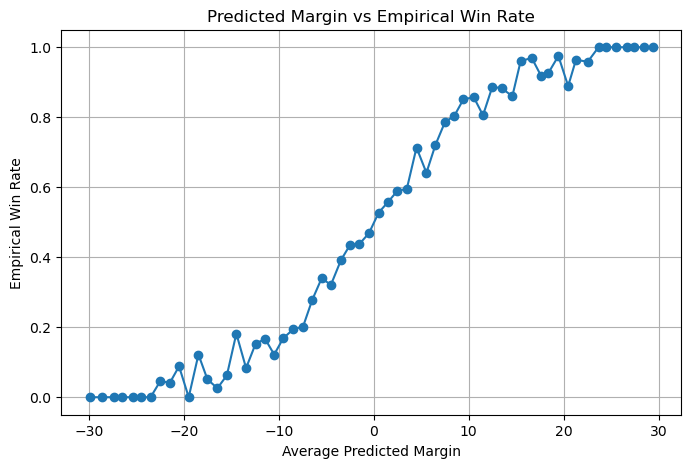

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_plot = tourney_data.copy()

# 只保留有预测值的行
df_plot = df_plot[df_plot["pred_margin"].notna()].copy()

# 可选：把极端值截一下，避免两端太稀疏
df_plot["pred_margin_clip"] = df_plot["pred_margin"].clip(-30, 30)

# 每 1 分一个 bin
bins = np.arange(-30, 31, 1)

df_plot["margin_bin"] = pd.cut(
    df_plot["pred_margin_clip"],
    bins=bins,
    right=False,
    include_lowest=True
)

plot_df = (
    df_plot.groupby("margin_bin")
    .agg(
        avg_pred_margin=("pred_margin_clip", "mean"),
        win_rate=("win", "mean"),
        count=("win", "size")
    )
    .reset_index()
)

# 可选：去掉样本太少的 bin，比如少于 10 个
plot_df = plot_df[plot_df["count"] >= 10]

plt.figure(figsize=(8, 5))
plt.plot(plot_df["avg_pred_margin"], plot_df["win_rate"], marker="o")
plt.xlabel("Average Predicted Margin")
plt.ylabel("Empirical Win Rate")
plt.title("Predicted Margin vs Empirical Win Rate")
plt.grid(True)
plt.show()

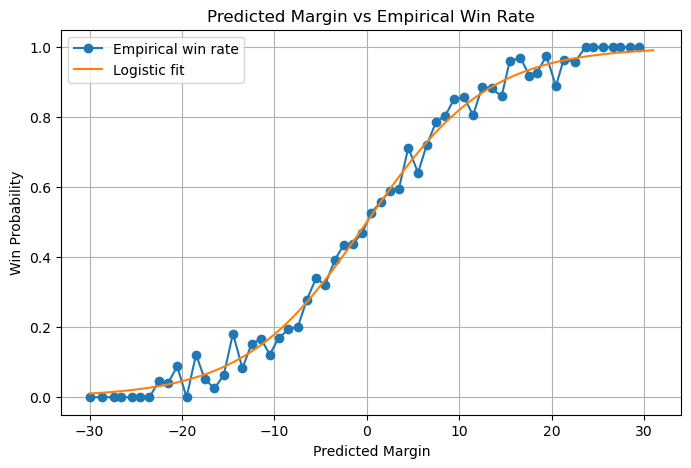

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# 经验曲线 plot_df 假设你已经有了
# 列包括：
# plot_df["avg_pred_margin"]
# plot_df["win_rate"]

# 生成连续横轴
x_grid = np.linspace(-30, 31, 300).reshape(-1, 1)

# 用拟合好的 logistic 模型算概率
logistic_curve = log_model.predict_proba(x_grid)[:, 1]

plt.figure(figsize=(8, 5))

# 经验曲线
plt.plot(
    plot_df["avg_pred_margin"],
    plot_df["win_rate"],
    marker="o",
    label="Empirical win rate"
)

# logistic 曲线
plt.plot(
    x_grid.ravel(),
    logistic_curve,
    label="Logistic fit"
)

plt.xlabel("Predicted Margin")
plt.ylabel("Win Probability")
plt.title("Predicted Margin vs Empirical Win Rate")
plt.grid(True)
plt.legend()
plt.show()

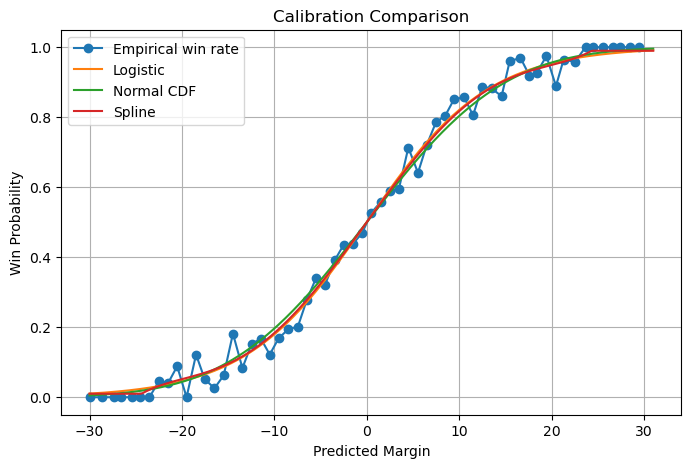

In [96]:
from scipy.stats import norm

# 例子：best_sigma 是你之前选好的 sigma
cdf_curve = norm.cdf(x_grid.ravel() / sigma)

# spline_model 是你用全体 OOF 数据拟合出来、仅用于展示的 spline
spline_curve = np.clip(spline_model(x_grid.ravel()), 0.01, 0.99)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["avg_pred_margin"],
    plot_df["win_rate"],
    marker="o",
    label="Empirical win rate"
)

plt.plot(x_grid.ravel(), logistic_curve, label="Logistic")
plt.plot(x_grid.ravel(), cdf_curve, label="Normal CDF")
plt.plot(x_grid.ravel(), spline_curve, label="Spline")

plt.xlabel("Predicted Margin")
plt.ylabel("Win Probability")
plt.title("Calibration Comparison")
plt.grid(True)
plt.legend()
plt.show()

In [88]:
models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    test=tourney_data[tourney_data['men_women']==1]
    x_train = test.loc[test["Season"] != oof_season, features].values
    y_train = test.loc[test["Season"] != oof_season, "PointDiff"].values
    x_val = test.loc[test["Season"] == oof_season, features].values
    y_val = test.loc[test["Season"] == oof_season, "PointDiff"].values
    s_val = test.loc[test["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train, feature_names=features)
    dval = xgb.DMatrix(x_val, label=y_val, feature_names=features)

    models[oof_season] = xgb.train(
      params = xgb_parameters,
      dtrain = dtrain,
      num_boost_round = 400, 
      obj = cauchyobj,
    )
    
    preds = models[oof_season].predict(dval)
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"average mae: {np.mean(oof_mae)}")

oof season 2003 mae: 8.97483890572718
oof season 2004 mae: 7.853249299136385
oof season 2005 mae: 7.686631598965162
oof season 2006 mae: 8.825381024238757
oof season 2007 mae: 7.615906808396296
oof season 2008 mae: 9.682930884911912
oof season 2009 mae: 9.675967952064497
oof season 2010 mae: 7.833957483218466
oof season 2011 mae: 8.78252992707445
oof season 2012 mae: 7.682840515503423
oof season 2013 mae: 11.300405899546176
oof season 2014 mae: 8.941886521554606
oof season 2015 mae: 7.719001362047732
oof season 2016 mae: 9.855601976275642
oof season 2017 mae: 8.147580330175153
oof season 2018 mae: 9.086912186047376
oof season 2019 mae: 9.512028163036403
oof season 2021 mae: 10.168967729669555
oof season 2022 mae: 10.269649730976147
oof season 2023 mae: 9.251106164813548
oof season 2024 mae: 10.525205490415665
oof season 2025 mae: 8.393486079415476
average mae: 8.990275728782272


In [89]:
models[2023].get_score()

{'T1_seed': 459.0,
 'T2_seed': 455.0,
 'Seed_diff': 1234.0,
 'T1_avg_Score': 1066.0,
 'T1_avg_FGA': 1116.0,
 'T1_awins': 938.0,
 'T2_awins': 1013.0,
 'T1_away_wins': 915.0,
 'T2_away_wins': 842.0,
 'T1_WinRatio14d': 469.0,
 'T2_WinRatio14d': 440.0,
 'cb_preds1': 1075.0,
 'cb_preds2': 1047.0,
 'T1_avg_Blk': 991.0,
 'T1_avg_PF': 1286.0,
 'T1_avg_opponent_FGA': 1345.0,
 'T1_avg_opponent_Blk': 1107.0,
 'T1_avg_opponent_PF': 1248.0,
 'T1_avg_PointDiff': 1079.0,
 'T2_avg_Score': 1047.0,
 'T2_avg_FGA': 1122.0,
 'T2_avg_Blk': 1030.0,
 'T2_avg_PF': 1253.0,
 'T2_avg_opponent_FGA': 1289.0,
 'T2_avg_opponent_Blk': 1150.0,
 'T2_avg_opponent_PF': 1288.0,
 'T2_avg_PointDiff': 1119.0,
 'T1_elo': 1012.0,
 'T2_elo': 1002.0,
 'elo_diff': 1302.0,
 'T1_quality': 1978.0,
 'T2_quality': 2005.0}

In [90]:
sorted(models[2010].get_score().items(), key=lambda x:x[1], reverse=True)

[('T1_quality', 2091.0),
 ('T2_quality', 2004.0),
 ('T2_avg_PF', 1358.0),
 ('T1_avg_opponent_FGA', 1338.0),
 ('T2_avg_opponent_PF', 1321.0),
 ('T2_avg_opponent_FGA', 1317.0),
 ('elo_diff', 1310.0),
 ('T1_avg_PF', 1285.0),
 ('T1_avg_opponent_PF', 1279.0),
 ('Seed_diff', 1235.0),
 ('cb_preds1', 1151.0),
 ('T1_avg_Blk', 1134.0),
 ('T2_avg_PointDiff', 1131.0),
 ('T1_avg_opponent_Blk', 1129.0),
 ('T2_avg_opponent_Blk', 1128.0),
 ('T2_avg_Blk', 1119.0),
 ('T1_avg_PointDiff', 1110.0),
 ('T1_avg_FGA', 1083.0),
 ('T2_avg_FGA', 1070.0),
 ('cb_preds2', 1051.0),
 ('T1_avg_Score', 980.0),
 ('T2_avg_Score', 976.0),
 ('T1_elo', 961.0),
 ('T1_awins', 945.0),
 ('T2_elo', 931.0),
 ('T2_awins', 909.0),
 ('T1_away_wins', 849.0),
 ('T2_away_wins', 818.0),
 ('T1_seed', 490.0),
 ('T2_seed', 447.0),
 ('T1_WinRatio14d', 426.0),
 ('T2_WinRatio14d', 419.0)]

In [91]:
importance_dict = {}

for oof_season in set(tourney_data.Season):
    imp = models[oof_season].get_score(importance_type="gain")
    imp_sorted = sorted(imp.items(), key=lambda x: x[1], reverse=True)
    importance_dict[oof_season] = imp_sorted

In [92]:
importance_dict

{2003: [('Seed_diff', 8818.490234375),
  ('T1_seed', 2749.390625),
  ('T2_seed', 2597.83203125),
  ('elo_diff', 2495.953125),
  ('T2_quality', 1974.9100341796875),
  ('T1_quality', 1874.0504150390625),
  ('T2_awins', 1132.23046875),
  ('T1_awins', 1094.1241455078125),
  ('T2_avg_PointDiff', 1030.9151611328125),
  ('T1_avg_PointDiff', 1030.814697265625),
  ('T2_elo', 985.1864013671875),
  ('T1_elo', 963.7120361328125),
  ('cb_preds2', 867.7027587890625),
  ('T2_avg_opponent_FGA', 805.37646484375),
  ('T1_avg_opponent_FGA', 804.7841796875),
  ('T1_avg_opponent_PF', 803.5859985351562),
  ('T1_avg_Score', 799.1945190429688),
  ('T2_avg_opponent_PF', 798.5326538085938),
  ('T2_avg_PF', 796.6444091796875),
  ('T1_WinRatio14d', 794.0355224609375),
  ('T2_avg_FGA', 793.8334350585938),
  ('T1_avg_PF', 793.6264038085938),
  ('T2_WinRatio14d', 790.09033203125),
  ('T2_avg_Score', 788.3643188476562),
  ('T1_avg_FGA', 786.9647827148438),
  ('T2_away_wins', 778.4251708984375),
  ('T1_avg_opponent_Bl

In [93]:
importance_dict = {}

for oof_season in set(tourney_data.Season):
    imp = models[oof_season].get_score()
    imp_sorted = sorted(imp.items(), key=lambda x: x[1], reverse=True)
    importance_dict[oof_season] = imp_sorted

In [94]:
importance_dict

{2003: [('T2_quality', 2007.0),
  ('T1_quality', 2001.0),
  ('T2_avg_PF', 1383.0),
  ('T2_avg_opponent_FGA', 1379.0),
  ('T1_avg_opponent_FGA', 1338.0),
  ('T2_avg_opponent_PF', 1317.0),
  ('T1_avg_opponent_PF', 1286.0),
  ('T1_avg_PF', 1276.0),
  ('elo_diff', 1255.0),
  ('Seed_diff', 1234.0),
  ('T2_avg_FGA', 1158.0),
  ('cb_preds1', 1143.0),
  ('T2_avg_Score', 1129.0),
  ('T1_avg_Score', 1107.0),
  ('T2_avg_opponent_Blk', 1106.0),
  ('T1_avg_PointDiff', 1097.0),
  ('T1_avg_FGA', 1070.0),
  ('T2_avg_PointDiff', 1068.0),
  ('T1_avg_opponent_Blk', 1053.0),
  ('T1_avg_Blk', 1010.0),
  ('cb_preds2', 1000.0),
  ('T1_elo', 983.0),
  ('T2_avg_Blk', 969.0),
  ('T2_awins', 967.0),
  ('T2_elo', 931.0),
  ('T1_awins', 916.0),
  ('T2_away_wins', 837.0),
  ('T1_away_wins', 827.0),
  ('T1_seed', 516.0),
  ('T2_WinRatio14d', 492.0),
  ('T2_seed', 480.0),
  ('T1_WinRatio14d', 477.0)],
 2004: [('T2_quality', 2034.0),
  ('T1_quality', 1970.0),
  ('T2_avg_opponent_FGA', 1415.0),
  ('T1_avg_opponent_FGA'

In [95]:
regular_data['Season'].unique()

array([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025])

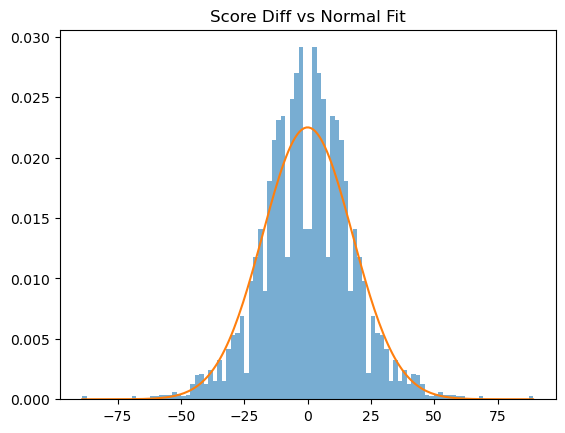

In [97]:
import numpy as np
from scipy.stats import norm

data = tourney_data["PointDiff"]

mu = data.mean()
sigma = data.std()

x = np.linspace(data.min(), data.max(), 200)

plt.hist(data, bins=100, density=True, alpha=0.6)
plt.plot(x, norm.pdf(x, mu, sigma))
plt.title("Score Diff vs Normal Fit")
plt.show()

In [98]:
import numpy as np
import pandas as pd

oof_preds = np.array(oof_preds)
oof_targets = np.array(oof_targets)

oof_win = (oof_targets > 0).astype(int)

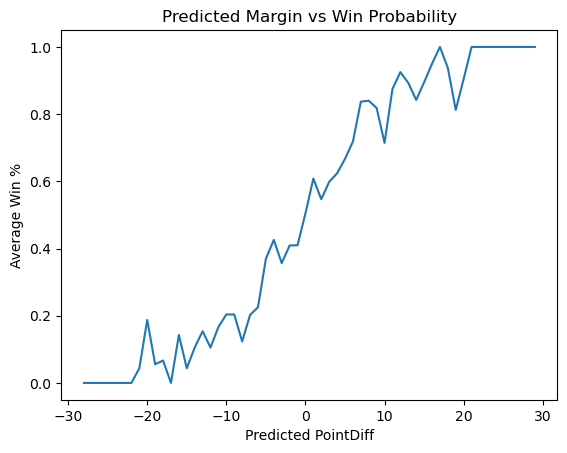

In [108]:
df = pd.DataFrame({
    "pred": oof_preds,
    "label": (np.array(oof_targets) > 0).astype(int)
})

df["pred_pointdiff"] = df["pred"].astype(int)

xdf = (
    df.clip(-30, 30)
      .groupby("pred_pointdiff")["label"]
      .mean()
      .reset_index(name="win_rate")
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x="pred_pointdiff", y="win_rate", data=xdf)
plt.xlabel("Predicted PointDiff")
plt.ylabel("Average Win %")
plt.title("Predicted Margin vs Win Probability")
plt.show()

brier: 0.1858800153770376


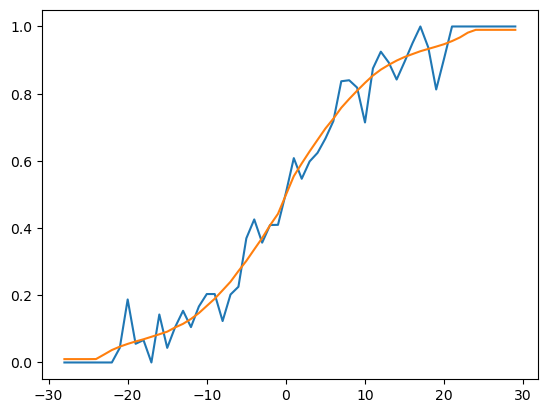

In [110]:
from scipy.interpolate import UnivariateSpline

t = 25
dat = list(zip(oof_preds, np.array(oof_targets)>0))
dat = sorted(dat, key = lambda x: x[0])
pred, label = list(zip(*dat))
#spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_pointdiff')[['spline','label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'],xdf['label'])
plt.plot(xdf['pred_pointdiff'],xdf['spline'])

In [122]:
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import brier_score_loss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 准备数据
margin = np.array(oof_preds)
win = (np.array(oof_targets) > 0).astype(int)

# 排序 (spline 需要)
dat = sorted(zip(margin, win), key=lambda x: x[0])
pred_sorted, label_sorted = zip(*dat)

pred_sorted = np.array(pred_sorted)
label_sorted = np.array(label_sorted)

k_list = [1,2,3,4,5]

n = len(pred_sorted)
s_list = np.arange(200, 401, 5)

results = []

for k in k_list:
    for s in s_list:

        try:

            spline_model = UnivariateSpline(
                np.clip(pred_sorted,-t,t),
                label_sorted,
                k=k,
                s=s
            )

            prob = np.clip(
                spline_model(np.clip(margin,-t,t)),
                0.01,
                0.99
            )

            brier = brier_score_loss(win, prob)

            print(f"k={k}, s={s}, brier={brier:.6f}")

            results.append((k,s,brier))

        except Exception as e:

            print(f"k={k}, s={s}, failed: {e}")
results_df = pd.DataFrame(results, columns=["k","s","brier"])
results_df = results_df.sort_values("brier")

print(results_df)

k=1, s=200, brier=0.067814
k=1, s=205, brier=0.069547
k=1, s=210, brier=0.071308
k=1, s=215, brier=0.073046
k=1, s=220, brier=0.074779
k=1, s=225, brier=0.076572
k=1, s=230, brier=0.078363
k=1, s=235, brier=0.080150
k=1, s=240, brier=0.081933
k=1, s=245, brier=0.083799
k=1, s=250, brier=0.085555
k=1, s=255, brier=0.087311
k=1, s=260, brier=0.089066
k=1, s=265, brier=0.090822
k=1, s=270, brier=0.092498
k=1, s=275, brier=0.094417
k=1, s=280, brier=0.096091
k=1, s=285, brier=0.097847
k=1, s=290, brier=0.098609
k=1, s=295, brier=0.100588
k=1, s=300, brier=0.102488
k=1, s=305, brier=0.104318
k=1, s=310, brier=0.106039
k=1, s=315, brier=0.107853
k=1, s=320, brier=0.109642
k=1, s=325, brier=0.111325
k=1, s=330, brier=0.113134
k=1, s=335, brier=0.114891
k=1, s=340, brier=0.116648
k=1, s=345, brier=0.118434
k=1, s=350, brier=0.120076
k=1, s=355, brier=0.121799
k=1, s=360, brier=0.123508
k=1, s=365, brier=0.125240
k=1, s=370, brier=0.127162
k=1, s=375, brier=0.128804
k=1, s=380, brier=0.130542
k

In [118]:
import numpy as np
import pandas as pd
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import brier_score_loss

df_cal = pd.DataFrame({
    "pred": np.array(oof_preds),
    "target": np.array(oof_targets),
    "Season": np.array(oof_ss)
})

df_cal["label"] = (df_cal["target"] > 0).astype(int)

seasons = sorted(df_cal["Season"].unique())

split_idx = int(len(seasons) * 0.8)
train_seasons = seasons[:split_idx]
val_seasons = seasons[split_idx:]

cal_train = df_cal[df_cal["Season"].isin(train_seasons)].copy()
cal_val = df_cal[df_cal["Season"].isin(val_seasons)].copy()

print("train seasons:", train_seasons)
print("val seasons:", val_seasons)


k_list = [1, 2, 3, 4, 5]
s_list = [None, 200, 500, 1000, 1500, 2230, 3000, 5000]
t = 25

results = []

# spline 要求 x 排序
train_dat = sorted(zip(cal_train["pred"], cal_train["label"]), key=lambda x: x[0])
pred_sorted, label_sorted = zip(*train_dat)

pred_sorted = np.array(pred_sorted)
label_sorted = np.array(label_sorted)

for k in k_list:
    for s in s_list:
        try:
            spline_model = UnivariateSpline(
                np.clip(pred_sorted, -t, t),
                label_sorted,
                k=k,
                s=s
            )

            val_prob = np.clip(
                spline_model(np.clip(cal_val["pred"].values, -t, t)),
                0.01,
                0.99
            )

            brier = brier_score_loss(cal_val["label"].values, val_prob)

            results.append({
                "k": k,
                "s": s,
                "brier": brier
            })

            print(f"k={k}, s={s}, brier={brier:.6f}")

        except Exception as e:
            print(f"k={k}, s={s}, failed: {e}")

train seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
val seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
k=1, s=None, brier=0.194746
k=1, s=200, brier=0.262408
k=1, s=500, brier=0.194746
k=1, s=1000, brier=0.194746
k=1, s=1500, brier=0.194746
k=1, s=2230, brier=0.194746
k=1, s=3000, brier=0.194746
k=1, s=5000, brier=0.194746
k=2, s=None, brier=0.194751
k=2, s=200, brier=0.298632
k=2, s=500, brier=0.194751
k=2, s=1000, brier=0.194751
k=2, s=1500, brier=0.194751
k=2, s=2230, brier=0.194751
k=2, s=3000, brier=0.194751
k=2, s=5000, brier=0.194751
k=3, s=None, brier=0.195041
k=3, s=200, brier=0.282099
k=3, s=500, brier=0.195041
k=3, s=1000, brier=0.195041
k=3, s=1500, brier=0.195041
k=3, s=2230, brier=0.195041
k=3, s=3

In [119]:
results_df = pd.DataFrame(results, columns=["k", "s", "brier"]).sort_values("brier")
print(results_df)

    k       s     brier
39  5  5000.0  0.194683
37  5  2230.0  0.194683
36  5  1500.0  0.194683
35  5  1000.0  0.194683
34  5   500.0  0.194683
32  5     NaN  0.194683
38  5  3000.0  0.194683
0   1     NaN  0.194746
4   1  1500.0  0.194746
2   1   500.0  0.194746
7   1  5000.0  0.194746
6   1  3000.0  0.194746
5   1  2230.0  0.194746
3   1  1000.0  0.194746
15  2  5000.0  0.194751
8   2     NaN  0.194751
13  2  2230.0  0.194751
12  2  1500.0  0.194751
11  2  1000.0  0.194751
10  2   500.0  0.194751
14  2  3000.0  0.194751
26  4   500.0  0.195041
31  4  5000.0  0.195041
30  4  3000.0  0.195041
29  4  2230.0  0.195041
24  4     NaN  0.195041
28  4  1500.0  0.195041
27  4  1000.0  0.195041
23  3  5000.0  0.195041
22  3  3000.0  0.195041
21  3  2230.0  0.195041
20  3  1500.0  0.195041
18  3   500.0  0.195041
16  3     NaN  0.195041
19  3  1000.0  0.195041
1   1   200.0  0.262408
25  4   200.0  0.280675
17  3   200.0  0.282099
33  5   200.0  0.288720
9   2   200.0  0.298632


2230

In [105]:
from scipy.stats import norm

sigma = np.std(oof_targets - oof_preds)

oof_prob_normal = 1 - norm.cdf(0, loc=oof_preds, scale=sigma)

print("Normal Brier:", brier_score_loss(oof_win, oof_prob_normal))
print("Normal LogLoss:", log_loss(oof_win, oof_prob_normal))

Normal Brier: 0.18598636828981985
Normal LogLoss: 0.5467521529952101


In [106]:
from sklearn.isotonic import IsotonicRegression

iso_cal = IsotonicRegression(out_of_bounds="clip")
iso_cal.fit(oof_preds, oof_win)

oof_prob_iso = iso_cal.predict(oof_preds)

print("Isotonic Brier:", brier_score_loss(oof_win, oof_prob_iso))
print("Isotonic LogLoss:", log_loss(oof_win, oof_prob_iso))

Isotonic Brier: 0.18313634013287583
Isotonic LogLoss: 0.5369976367730068


In [107]:
import gc
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

brier_list_iso = []
logloss_list_iso = []
isotonic_dict = {}

test = tourney_data[tourney_data["men_women"] == 1].copy()

for oof_season in sorted(test["Season"].unique()):
    gc.collect()
    
    train_idx = test["Season"] != oof_season
    val_idx = test["Season"] == oof_season
    
    x_train = test.loc[train_idx, features].values
    y_train = test.loc[train_idx, "PointDiff"].values
    x_val = test.loc[val_idx, features].values
    y_val = test.loc[val_idx, "PointDiff"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train, feature_names=features)
    dval = xgb.DMatrix(x_val, label=y_val, feature_names=features)
    
    pred_train_margin = models[oof_season].predict(dtrain)
    pred_val_margin = models[oof_season].predict(dval)
    
    y_train_bin = (y_train > 0).astype(int)
    y_val_bin = (y_val > 0).astype(int)
    
    calibrater = IsotonicRegression(out_of_bounds="clip")
    calibrater.fit(pred_train_margin, y_train_bin)
    
    isotonic_dict[oof_season] = calibrater
    
    preds = calibrater.predict(pred_val_margin)
    
    bscore = brier_score_loss(y_val_bin, preds)
    ll = log_loss(y_val_bin, np.clip(preds, 1e-6, 1 - 1e-6))
    
    brier_list_iso.append(bscore)
    logloss_list_iso.append(ll)
    
    print(f"oof season {oof_season} isotonic brier: {bscore:.6f}, logloss: {ll:.6f}")

print("Average isotonic brier:", np.mean(brier_list_iso))

oof season 2003 isotonic brier: 0.211590, logloss: 0.606033
oof season 2004 isotonic brier: 0.177819, logloss: 0.518118
oof season 2005 isotonic brier: 0.164923, logloss: 0.496455
oof season 2006 isotonic brier: 0.212957, logloss: 0.609147
oof season 2007 isotonic brier: 0.127356, logloss: 0.393053
oof season 2008 isotonic brier: 0.147361, logloss: 0.442530
oof season 2009 isotonic brier: 0.175892, logloss: 0.504304
oof season 2010 isotonic brier: 0.201019, logloss: 0.576473
oof season 2011 isotonic brier: 0.245050, logloss: 0.693491
oof season 2012 isotonic brier: 0.191574, logloss: 0.717061
oof season 2013 isotonic brier: 0.221473, logloss: 0.647197
oof season 2014 isotonic brier: 0.230832, logloss: 0.650558
oof season 2015 isotonic brier: 0.160397, logloss: 0.646601
oof season 2016 isotonic brier: 0.199076, logloss: 0.745703
oof season 2017 isotonic brier: 0.196388, logloss: 0.555629
oof season 2018 isotonic brier: 0.217978, logloss: 0.810947
oof season 2019 isotonic brier: 0.156818